In [3]:
import pandas as pd
df = pd.read_csv("/Users/wmhjoy/Data_Mining_Project/data/processed/nhanes_clean.csv")
df.head()


,id,age,gender,race,education,income_poverty_ratio,weight_kg,height_cm,bmi,sbp,...,a1c,glucose,smoking_current,smoking_ever,physical_activity_freq,sleep_hours,diabetes_self_report,has_health_insurance,doctor_visit_12m,insurance_type
0,130378.0,43.0,Male,Non-Hispanic Asian,College graduate or above,5.00,86.9,179.5,27.0,135.0,...,5.6,113.0,Yes,Unknown,45.0,9.5,No,Insured,Yes,Private only
1,130379.0,66.0,Male,Non-Hispanic White,College graduate or above,5.00,101.8,174.2,33.5,121.0,...,5.6,99.0,Yes,Unknown,45.0,9.0,No,Insured,Unknown,Both
2,130380.0,44.0,Female,Other Hispanic,High school/GED,1.41,69.4,152.9,29.7,111.0,...,6.2,156.0,No,Unknown,30.0,8.0,Yes,Insured,Unknown,Public only
3,130381.0,5.0,Female,Other Race / Multi,Unknown,1.53,34.3,120.1,23.8,117.0,...,5.5,100.0,Unknown,Unknown,45.0,8.0,No,Insured,Yes,Public only
4,130382.0,2.0,Male,Non-Hispanic White,Unknown,3.60,13.6,105.0,16.3,117.0,...,5.5,100.0,Unknown,Unknown,45.0,8.0,No,Insured,Unknown,Private only


In [4]:
df.info()
df.describe().round(2)
df.isna().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11933 entries, 0 to 11932
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   id                      11933 non-null  float64
 1   age                     11933 non-null  float64
 2   gender                  11933 non-null  object 
 3   race                    11933 non-null  object 
 4   education               11933 non-null  object 
 5   income_poverty_ratio    11933 non-null  float64
 6   weight_kg               11933 non-null  float64
 7   height_cm               11933 non-null  float64
 8   bmi                     11933 non-null  float64
 9   sbp                     11933 non-null  float64
 10  dbp                     11933 non-null  float64
 11  a1c                     11933 non-null  float64
 12  glucose                 11933 non-null  float64
 13  smoking_current         11933 non-null  object 
 14  smoking_ever            11933 non-null

id                        0
age                       0
gender                    0
race                      0
education                 0
income_poverty_ratio      0
weight_kg                 0
height_cm                 0
bmi                       0
sbp                       0
dbp                       0
a1c                       0
glucose                   0
smoking_current           0
smoking_ever              0
physical_activity_freq    0
sleep_hours               0
diabetes_self_report      0
has_health_insurance      0
doctor_visit_12m          0
insurance_type            0
dtype: int64

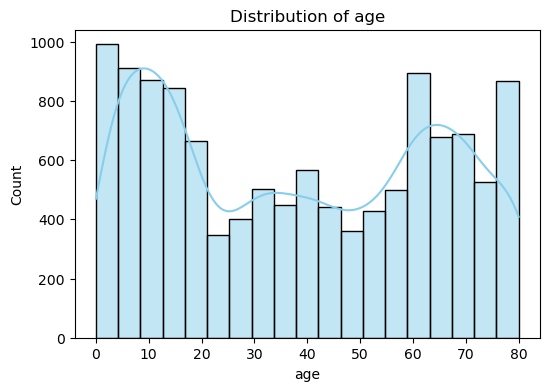

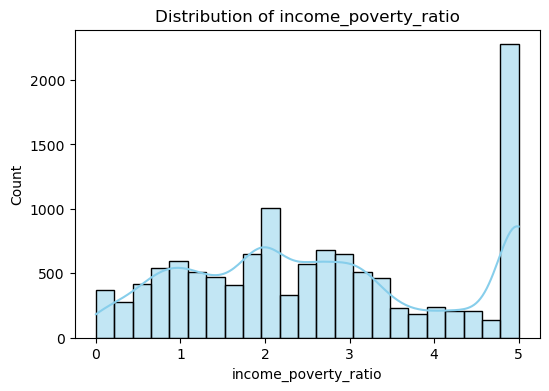

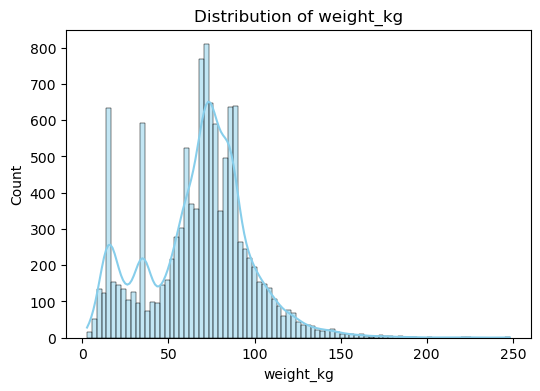

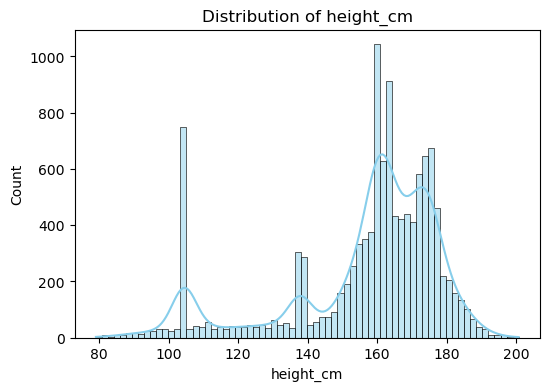

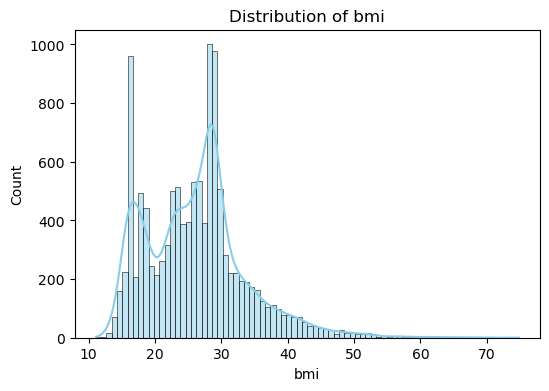

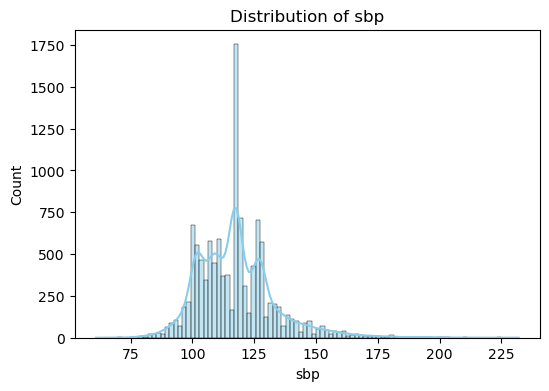

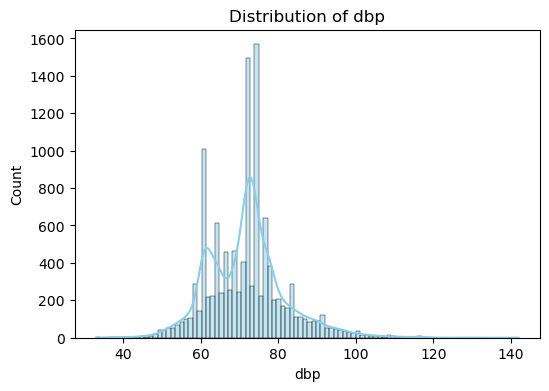

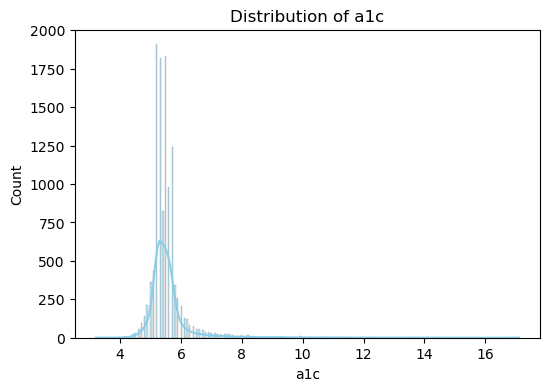

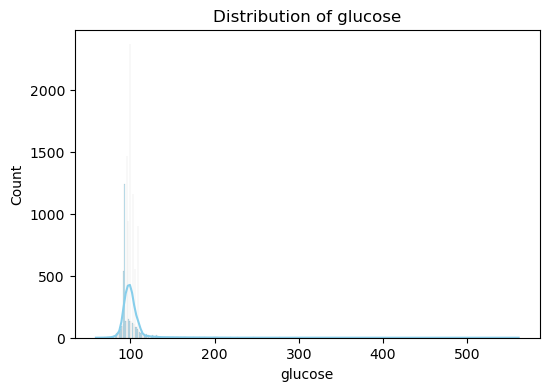

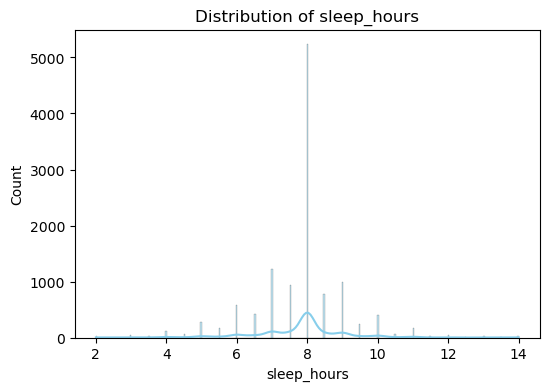

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns

num_cols = ['age', 'income_poverty_ratio', 'weight_kg', 'height_cm',
            'bmi', 'sbp', 'dbp', 'a1c', 'glucose', 'sleep_hours']

for col in num_cols:
    plt.figure(figsize=(6,4))
    sns.histplot(df[col], kde=True, color='skyblue')
    plt.title(f"Distribution of {col}")
    plt.show()


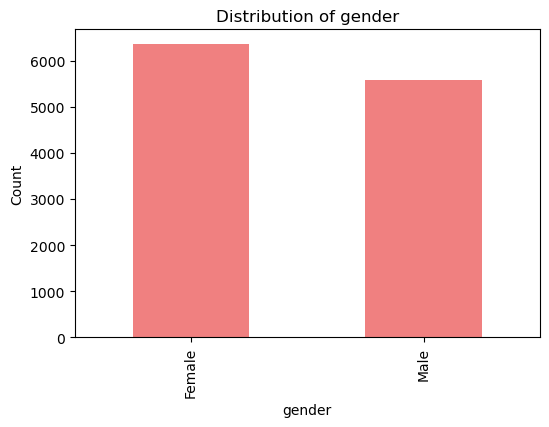

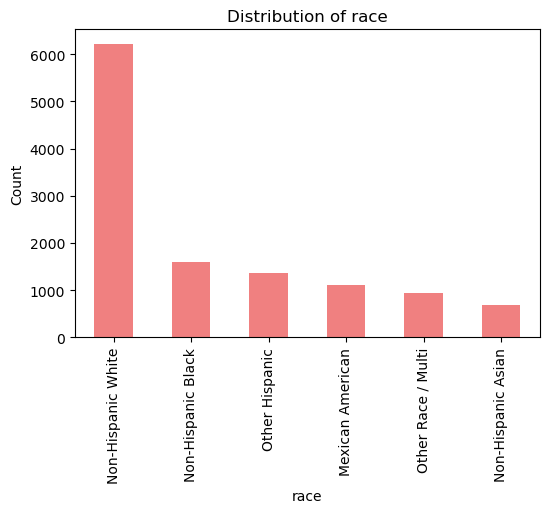

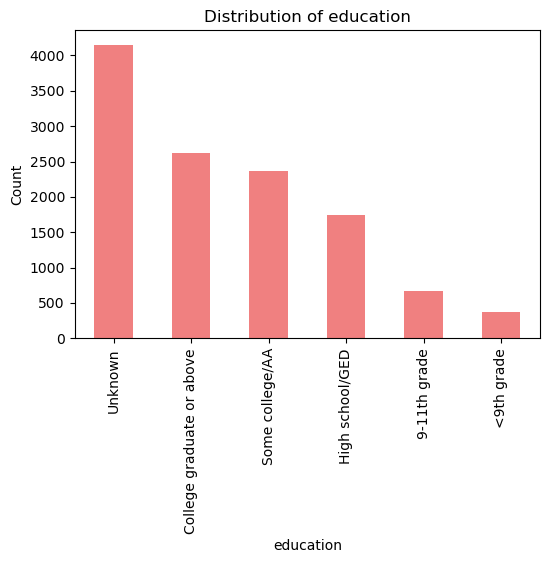

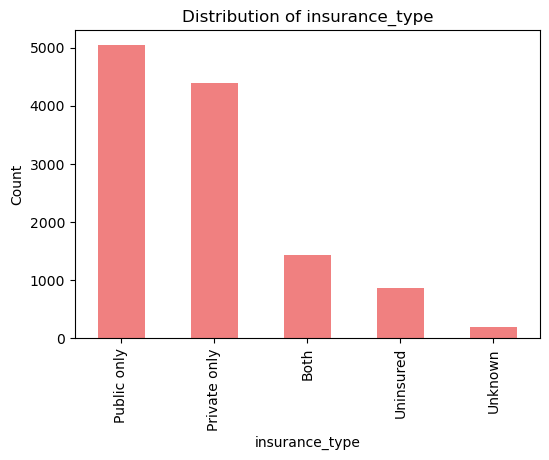

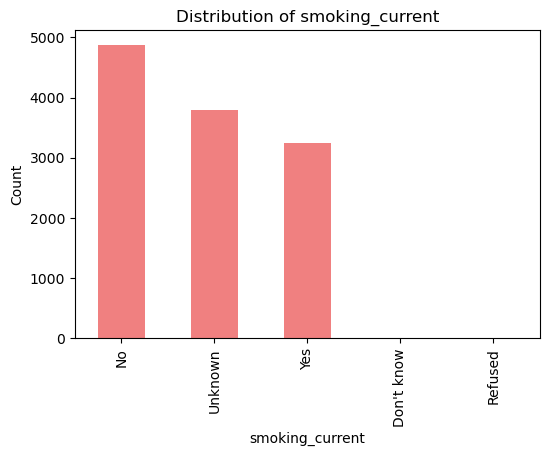

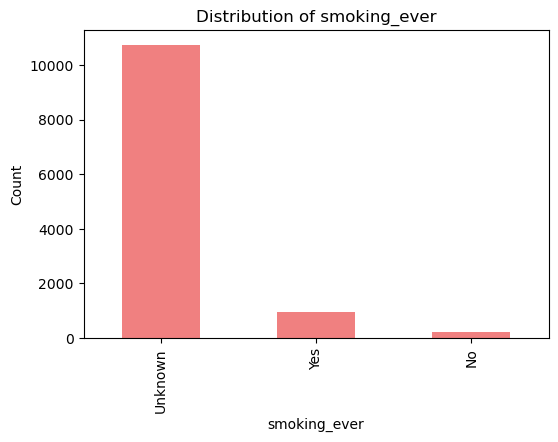

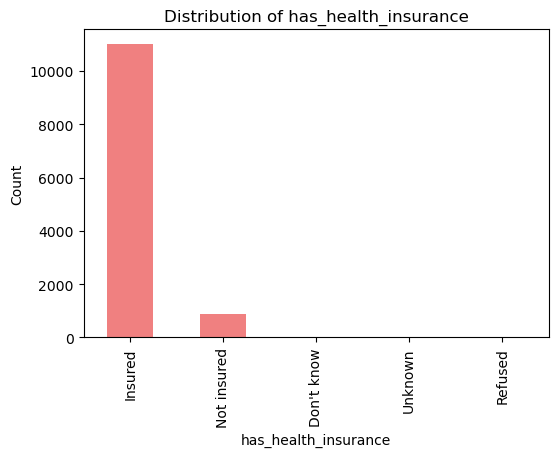

In [6]:
cat_cols = ['gender', 'race', 'education', 'insurance_type', 
            'smoking_current', 'smoking_ever', 'has_health_insurance']

for col in cat_cols:
    plt.figure(figsize=(6,4))
    df[col].value_counts(dropna=False).plot(kind='bar', color='lightcoral')
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.show()


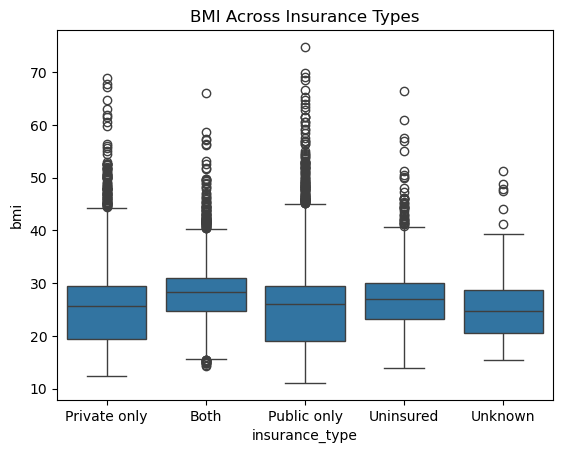

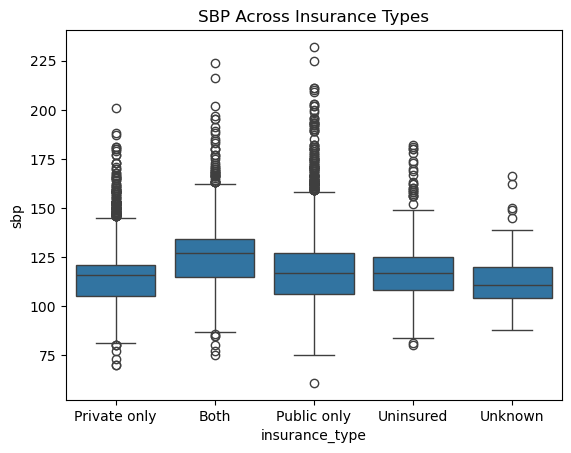

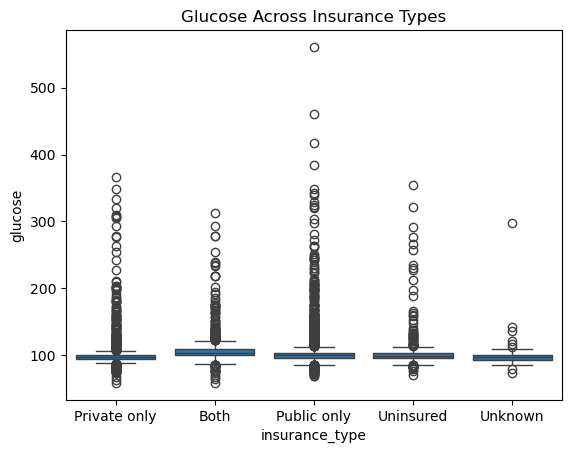

In [7]:
sns.boxplot(x='insurance_type', y='bmi', data=df)
plt.title("BMI Across Insurance Types")
plt.show()

sns.boxplot(x='insurance_type', y='sbp', data=df)
plt.title("SBP Across Insurance Types")
plt.show()

sns.boxplot(x='insurance_type', y='glucose', data=df)
plt.title("Glucose Across Insurance Types")
plt.show()


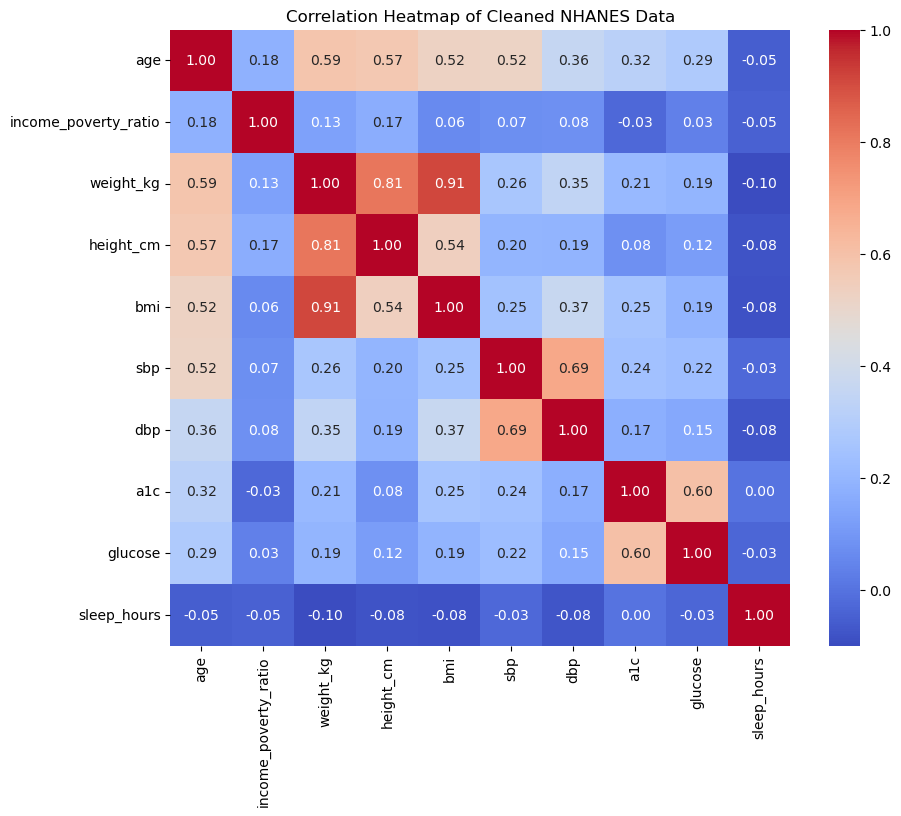

In [8]:
plt.figure(figsize=(10,8))
sns.heatmap(df[num_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap of Cleaned NHANES Data")
plt.show()


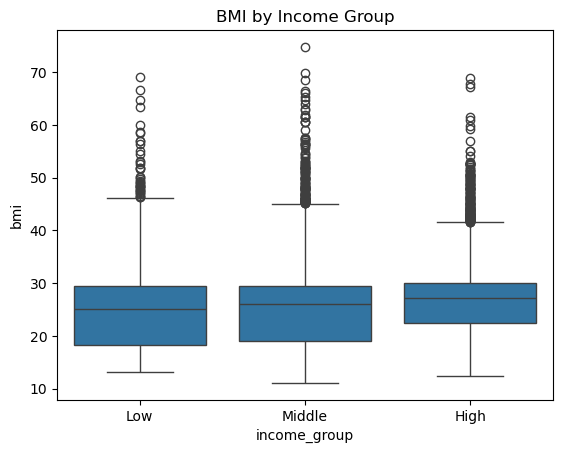

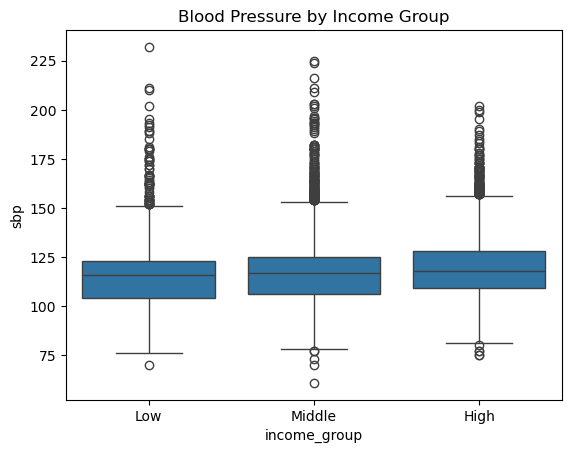

In [9]:
df['income_group'] = pd.cut(df['income_poverty_ratio'],
                            bins=[0,1,3,5],
                            labels=['Low', 'Middle', 'High'])

sns.boxplot(x='income_group', y='bmi', data=df)
plt.title("BMI by Income Group")
plt.show()

sns.boxplot(x='income_group', y='sbp', data=df)
plt.title("Blood Pressure by Income Group")
plt.show()


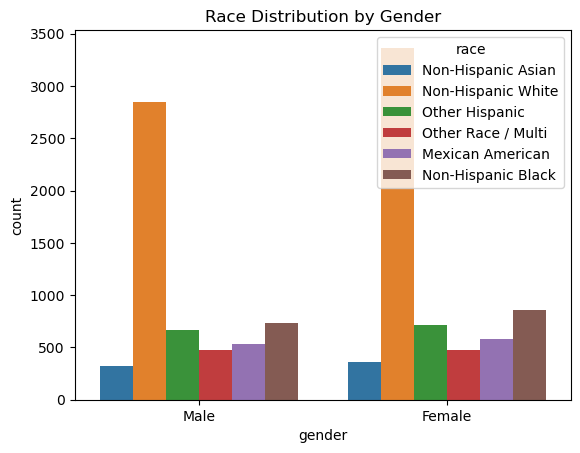

In [10]:
sns.countplot(x='gender', hue='race', data=df)
plt.title("Race Distribution by Gender")
plt.show()
